In [13]:
import sys 
sys.path.append("/home/feity/cryoem/")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import torch
import importlib 
import modules
import data

import postprocess 

import pickle
importlib.reload(data)
importlib.reload(modules)
importlib.reload(postprocess)

<module 'postprocess' from '/home/feity/cryoem/postprocess.py'>

In [2]:
# load model
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1", "stage3/epoch=6-total_validate_loss=1.3150.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_3", "stage3/epoch=13-total_validate_loss=1.5187.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_3", "stage1/epoch=116-total_validate_loss=1.9223.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_new", "stage2/epoch=22-total_validate_loss=0.0345.ckpt")
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_moretv", "stage2/epoch=16-total_validate_loss=0.0316.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold4_moretv", "stage2/epoch=22-total_validate_loss=0.0370.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold4_new", "stage2/epoch=21-total_validate_loss=0.0466.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold4_3", "stage2/epoch=22-total_validate_loss=0.6789.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/whole", "stage3/epoch=7-total_validate_loss=0.5072.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_2", "stage3/epoch=0-total_validate_loss=1.1893.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_mn", "stage3/last.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_mn", "stage1/last.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold3", "stage3/epoch=2-total_validate_loss=2.6516.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_ribo", "stage3/epoch=7-total_validate_loss=0.0677.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_ribo_10", "stage3/epoch=7-total_validate_loss=0.0645.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold2_ribo", "stage3/epoch=5-total_validate_loss=0.0831.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_final/fold1_stage3_new", "epoch=4-total_validate_loss=0.9694.ckpt")
# # model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_mrc_hsp60/fold2", "stage3/epoch=7-total_validate_loss=0.0256.ckpt")
model = model.eval()  

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([2]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


model at stage  stage 1
model with output classes 3
model receiving class weights tensor([1.0000, 1.0000, 0.6000])
using consistency regularization coef 0.5


/home/feity/cryoem/utils.py:1091: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters ['additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight']
finish loading parameters


/home/feity/cryoem/utils.py:1129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters []
finish loading parameters


In [ ]:
# build test dataset and generate dataframe
# Note: make sure the gap is consistent with the model training
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl",
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_005_interpolate.pkl",
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl", 
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_005_interpolate.pkl",
    norm="hist",
    reshape=800,
    map_class={"mitochondria": 0, "nucleus": 1 },
    gap=5,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    mask_length=1,
    require_mask=True,
    filtermin=0
)
# dataset2 = data.TestDatasetMrc(
#     "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/tomo/24092024_9.62Apx.mrc",
#     norm="hist",
#     reshape=800,
#     length_for_average=10,
#     gap = 5
# )
# df, graphs = postprocess.generatedf(model, dataset, gap = 5, columns=["ribo", "None"])
df, graphs, masks = postprocess.generatedf(model, dataset, gap = 5, columns=["mitochondria", "nucleus", "None"], return_mask=True)
# df, graphs, masks = postprocess.generatedf(model, dataset, gap = 5, columns=["ribo", "mitochondria", "nucleus", "ER", "None"], return_mask=True)

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl
dataset map classes:  {'mitochondria': 0, 'nucleus': 1}
dataset length: 61


100%|██████████| 61/61 [01:13<00:00,  1.21s/it]


finish dataset
build graph
prepare df


100%|██████████| 60/60 [01:10<00:00,  1.17s/it]


finish dataset
build graph
prepare df


...

finish dataset
build graph
prepare df


100%|██████████| 60/60 [01:06<00:00,  1.10s/it]


finish dataset
build graph
prepare df


100%|██████████| 60/60 [01:06<00:00,  1.10s/it]


finish dataset
build graph
prepare df


In [14]:
graphs[1]

Data(x=[399, 263], edge_index=[2, 15347], y=[399], inter_edges=[15347], box_masks=[399], boxes=[399, 4], item_id=[399])

In [12]:
all_y= [i.y for i in graphs]
all_y = np.concatenate(all_y, axis=0)
all_x = [i.x for i in graphs]
all_x = np.concatenate(all_x, axis=0)
all_box_mask = [i.box_masks for i in graphs]
all_box_mask = np.concatenate(all_box_mask, axis=0)
all_itemid = [i.item_id for i in graphs]
all_itemid = np.concatenate(all_itemid, axis=0)

In [11]:
graphs[1]

Data(x=[416, 263], edge_index=[2, 19064], y=[416], inter_edges=[19064], box_masks=[416], boxes=[416, 4], item_id=[416])

In [ ]:
all_y= [i.y for i in graphs]
all_y = np.concatenate(all_y, axis=0)
all_x = [i.x for i in graphs]
all_x = np.concatenate(all_x, axis=0)
all_box_mask = [i.box_masks for i in graphs]
all_box_mask = np.concatenate(all_box_mask, axis=0)
all_itemid = [i.item_id for i in graphs]
all_itemid = np.concatenate(all_itemid, axis=0)
t = np.zeros_like(all_box_mask, dtype=np.int32)-1
cnt = 0
for i in range(len(t)):
    if all_box_mask[i]:
        t[i] = cnt
        cnt += 1
allres = {}

In [ ]:
from sklearn.metrics import roc_auc_score
refine_mask = {
    "nucleus":{"smooth": 4.0, "morph_open_kernal_size":(7, 7), "morph_close_kernal_size": (7, 7), "blur_ksize": (25, 25), "max_contours": 1, "apply_convex_hull":False}, 
    "mitochondria":{"smooth": 4.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (15, 15), "max_contours": 1, "apply_convex_hull":False}, 
    "endoplasmic_reticulum_or_Golgi":{"smooth": 1.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (11, 11), "max_contours": 1, "contour_area_threshold":250, "apply_convex_hull":False}, 
    "ribo":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
    "hsp60":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
}
mask_thres = {
    "ribo":0.75, 
    "hsp60":0.75, 
    "mitochondria":0.6,
    "nucleus":0.75,
    "endoplasmic_reticulum_or_Golgi":0.6,
    
}
scores = []
iou_scores = []

for i in range(len(t)):
    if all_y[i] == 0:
        x = torch.tensor(all_x[i][-256:]).unsqueeze(0)
        boxes = torch.tensor(df.iloc[i][["x", "y", "w", "h"]].values.astype(np.float32)).unsqueeze(0)
        data = dataset.__getitem__(pos=int(all_x[i][0]*500))
        # label = retdict["masks"][]
        pv = data["pixel_values"].unsqueeze(0).float().to(model.device)
        ground_truth = masks[t[i]][2]# .float().numpy()
        with torch.no_grad():
            model.stage = "stage mask"
            model.mask_head.TF = 1.0
            out = model(pixel_values = pv, embed = x, box = boxes) 
            out = torch.sigmoid(out).detach().cpu().numpy()
        scores.append(roc_auc_score(ground_truth.flatten(), out.flatten()))
        thres = np.max(out)*0.7
        if all_y[i] == 1:
            label = "nucleus"
        else:
            label = "mitochondria"  
        refined_mask = postprocess.refineMask(
            out.squeeze(), 
            thres=thres,
            **refine_mask[label]
        )
        iou_scores.append(postprocess.calc_iou(refined_mask, ground_truth))
        allres[f"%s_%d"%(all_itemid[i], int(all_x[i][0]*500))] = {
            "pred":out.squeeze(),
            "refined_mask":refined_mask,
            "ground_truth":ground_truth,
            "iou":iou_scores[-1],
            "score":scores[-1],
            "thres":thres,
        }
    # if i == 150:
    #     break
        # print(roc_auc_score(ground_truth.flatten(), out.flatten()))
        # break
        # print()

/tmp/ipykernel_2814751/670019795.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(all_x[i][-256:]).unsqueeze(0)
/tmp/ipykernel_2814751/670019795.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(all_x[i][-256:]).unsqueeze(0)
/tmp/ipykernel_2814751/670019795.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(all_x[i][-256:]).unsqueeze(0)
/tmp/ipykernel_2814751/670019795.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or s

In [86]:
df.iloc[i][["x", "y", "w", "h"]].values.astype(np.float32)

array([0.01117988, 0.13110559, 0.02464182, 0.22025783], dtype=float32)

In [87]:
out.shape

(1, 800, 800)

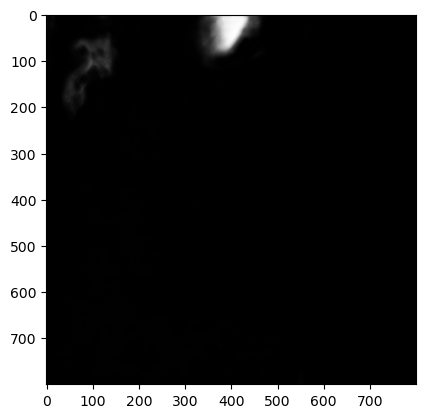

In [22]:
plt.imshow(out[0], cmap="gray")

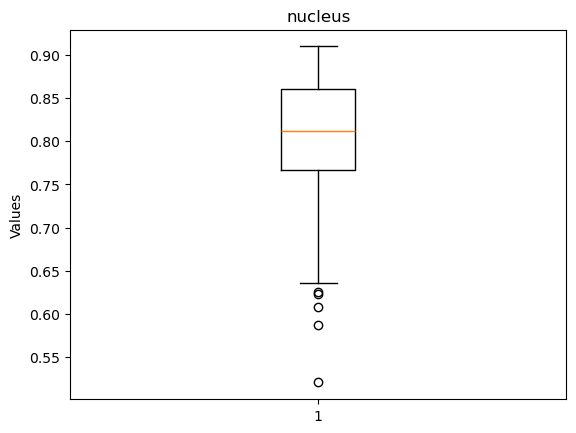

In [15]:
import matplotlib.pyplot as plt

# Example data
data = iou_scores

# Create box plot
plt.boxplot(data)

# Add labels and title
plt.title("nucleus")
plt.ylabel("Values")

# Show the plot
plt.show()


In [107]:
ground_truth.shape

(1, 1, 5, 800, 800)

In [86]:
retdict

dict_keys(['feature', 'label', 'masks', 'box_mask', 'boxes', 'item_id', 'images', 'pixel_masks', 'sample_mapping'])

In [50]:
with open("/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0081_interpolate.pkl", "rb") as f:
    sll39 = pickle.load(f)

masks_ribosome = np.zeros(sll39["mrc_shape"])
# sll39["masks"]["mitochondria"] = {}
labels = []
for i, j in sll39["masks"]["nucleus"].items():
    labels.extend(sll39["annotations"]["nucleus"][i])
    masks_ribosome[i] = j.toarray()
labels = np.unique(labels)
labels
# plt.imshow(masks_ribosome[220], cmap="gray")

array([], dtype=float64)

In [100]:
import numpy as np
from scipy.ndimage import center_of_mass

def get_labels_and_centers(label_matrix, labels=None):
    """
    Find all object labels and their centers in a 3D label matrix.

    Args:
        label_matrix: 3D NumPy array with 0 = background, 1,2,... = objects

    Returns:
        labels_1d: 1D NumPy array of object labels
        centers_2d: 2D NumPy array of shape (n_objects, 3)
                    with (z, y, x) coordinates for each object
    """
    # label_matrix = np.asarray(label_matrix)
    if labels is None:
        labels_id = np.unique(label_matrix)
        labels_id = labels_id[labels_id != 0]  # remove background
    else:
        labels_id = np.asarray(labels)

    centers_list = [
        center_of_mass(label_matrix == label_val)
        for label_val in labels_id
    ]

    centers_2d = np.array(centers_list)  # shape (n_objects, 3)

    return labels_id, centers_2d

labels, centers = get_labels_and_centers(masks_ribosome, labels)
print("Labels:", labels)
print("Centers:\n", centers)

Labels: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125]
Centers:
 [[ 92.42733111 156.91781637 272.97323977]
 [ 95.24893162 664.78573124 116.36016144]
 [136.53423842 287.52947481 306.07907586]
 [144.56359962 386.39051355 314.26652401]
 [148.41584394 586.7039372  293.36303081]
 [144.3411653  652.02764922 378.02539457]
 [156.47226511 515.37201568 325.18244447]
 [164.06969553 754.31755471 298.13356327]
 [158.86985976  85.91585453 118.28785358]
 [156.70564904 214.35456731 230.10745192]
 [164.89053781 574.06541612 420.40033242]
 [170.087586

In [6]:
import postprocess
importlib.reload(postprocess)

# pick out labels using clustering

df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1
df["largest"].value_counts()

# sllt0039
# important parameters for postprocessing
# min_samples and dis_penalty_cutoff
# if the size of the object changes throughout the tomogram, increase eps 
# if the object is small, add a little bit to enlarge the bounding box 

# params= {
#     "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 11, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 10}}, 
#     "nucleus":{"min_prob":0.3, "nms":0.4, "dbscan_prams":{"min_samples": 11, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 10}}, 
#     "ribo":{"min_prob":0.60, "nms":0.2, "dbscan_prams":{"min_samples":6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.03}}, 
#     "hsp60":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.03}}, 
# }

params= {
    "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 11, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 10}}, 
    "nucleus":{"min_prob":0.3, "nms":0.4, "dbscan_prams":{"min_samples": 11, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 10}}, 
    "ribo":{"min_prob":0.60, "nms":0.2, "dbscan_prams":{"min_samples":6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.03}}, 
    "hsp60":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.03}}, 
}

# myscan parameters
# params= {
#     "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "nucleus":{"min_prob":0.4, "nms":0.4, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "ribo":{"min_prob":0.60, "nms":0.2, "dbscan_prams":{"min_samples":6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.03}}, 
#     "hsp60":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.03}}, 
# }

mark_and_filter = {
    "nucleus":{"max_cnt":1, "remove_iou": 0.4, "min_samples":20}, 
    "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
    "endoplasmic_reticulum_or_Golgi":{"max_cnt":20, "remove_iou": 0.8, "min_samples":20}, 
    "ribo":{"max_cnt":500, "remove_iou": 0.5, "min_samples":10}, 
    "hsp60":{"max_cnt":500, "remove_iou": 0.5, "min_samples":6}, 
}

# sllt0081
# params= {
#     "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.4, "dis_penalty_coef": 10.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 20, "eps": 0.4, "dis_penalty_coef": 10.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "nucleus":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 20, "eps": 0.4, "dis_penalty_coef": 10.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "ribo":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 5, "eps": 0.4, "dis_penalty_coef": 20.0*(1/500), "dis_penalty_cutoff": 5}}, 
#     "hsp60":{"min_prob":0.35, "nms":0.2, "dbscan_prams":{"min_samples": 4, "eps": 0.4, "dis_penalty_coef": 20.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.04}}, 
# }

# mark_and_filter = {
#     "nucleus":{"max_cnt":2, "remove_iou": 0.4, "min_samples":30}, 
#     "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
#     "endoplasmic_reticulum_or_Golgi":{"max_cnt":20, "remove_iou": 0.8, "min_samples":20}, 
#     "ribo":{"max_cnt":500, "remove_iou": 0.5, "min_samples":5}, 
#     "hsp60":{"max_cnt":500, "remove_iou": 0.5, "min_samples":5}, 
# }

# call object detection, 
# object from larger to smaller is recommended
subdfs = []
for i in ["nucleus", "mitochondria"]:
# for i in ["nucleus"]:
# for i in ["hsp60"]:
# for i in ["ribo"]:
    subdf = postprocess.processClass(df, i, **params[i], use_myscan=False)
    subdfs.append(subdf)
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])




11 0.5 0.002 10
number of instances in class  1
11 0.5 0.002 10
number of instances in class  5


In [9]:
df[df["largest"] == "nucleus"]

,z,x,y,w,h,mitochondria,nucleus,None,max,largest,unlabeled,label,label_id,class_value
0,100,0.267396,0.148088,0.459061,0.305527,0.228907,0.387872,0.383221,0.387872,nucleus,True,,-1,0.228907


In [16]:
nucluesdf = df[df["label"] == "nucleus"]
nucluesdf["label_id"].value_counts()

Series([], Name: count, dtype: int64)

In [269]:
df["label"].value_counts()

label
                119289
mitochondria       333
nucleus             78
Name: count, dtype: int64

In [221]:
subdfs = pd.concat(subdfs)
subdfs.head()

,z,x,y,w,h,mitochondria,nucleus,None,max,largest,unlabeled,label,label_id,class_value,bbnms,area
0,140,0.046199,0.857501,0.088957,0.239417,0.192794,0.715684,0.091522,0.715684,nucleus,True,-1,-1,0.715684,True,0.021298
1,140,0.040778,0.604446,0.077684,0.150160,0.058975,0.890977,0.050048,0.890977,nucleus,True,-1,-1,0.890977,True,0.011665
5,140,0.046968,0.360285,0.093041,0.704239,0.050831,0.899598,0.049572,0.899598,nucleus,True,0,-1,0.899598,True,0.065523
144,141,0.046926,0.861619,0.093371,0.247807,0.335601,0.538498,0.125902,0.538498,nucleus,True,-1,-1,0.538498,True,0.023138
145,141,0.680674,0.444295,0.091356,0.919490,0.164549,0.706558,0.128893,0.706558,nucleus,True,-1,-1,0.706558,True,0.084001


In [156]:
subdf.iloc[[1], list(subdf.columns).index("bbnms")] = True

In [222]:
subdf = df[df["label"] == "nucleus"]
subdf["label_id"].value_counts()

label_id
0    169
Name: count, dtype: int64

In [ ]:

with open("/home/feity/cryoem/temp/results/sllt39_ribo.pkl", "rb") as f:
    d = pickle.load(f)
centers = d["centers"]

In [13]:
importlib.reload(postprocess)
score, predict_center = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
zmin = df["z"].min() 
zmax = df["z"].max() 
centers = centers[centers[:, 0]>=zmin]
centers = centers[centers[:, 0]<=zmax]
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, centers) 
roc, cnt = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
roc, cnt, cnt/len(centers)

(0.7258666345690901, 62, 0.5344827586206896)

In [14]:
len(score)

330

In [105]:
subdf = df
# subdf = subdf[(subdf["label"] != "")]
subdf = subdf[(subdf["label"] == "nucleus")]
subdf["label_id"].value_counts()

label_id
0    158
Name: count, dtype: int64

In [66]:
df["label_id"] = df["label_id"].apply(lambda x: -1 if x in [53, 29, 11, 3, 87] else x)
df["label_id"] = df["label_id"].apply(lambda x: 1 if x in [50] else x)

/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


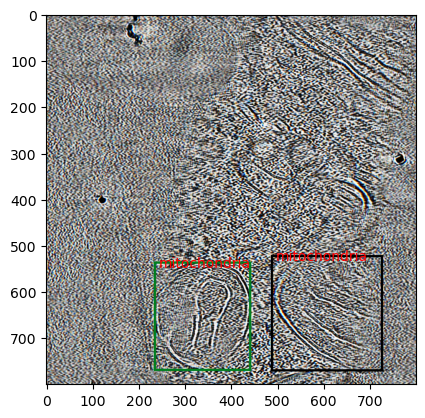

In [99]:
t = dataset.__getitem__(pos=290)
utils.drawannotation(t["pixel_values"], t["labels"], font_size=10, mask=False)

In [100]:
df.head()

,z,x,y,w,h,mitochondria,nucleus,None,max,largest,annotation,item_id,unlabeled,label,label_id,class_value
0,100,0.132132,0.531524,0.271574,0.929809,0.271447,0.512570,0.215983,0.512570,nucleus,1,nucleus_1,False,nucleus,0,0.271447
1,100,0.247463,0.505187,0.482160,0.985108,0.268000,0.511736,0.220264,0.511736,nucleus,4,,False,,-1,0.268000
2,105,0.135406,0.528127,0.279349,0.925587,0.270494,0.515399,0.214107,0.515399,nucleus,1,nucleus_1,False,,-1,0.270494
3,105,0.222252,0.506663,0.443425,0.990206,0.260320,0.517598,0.222082,0.517598,nucleus,4,,False,nucleus,0,0.260320
4,110,0.141354,0.525934,0.286515,0.930999,0.265893,0.517096,0.217012,0.517096,nucleus,1,nucleus_1,False,nucleus,0,0.265893


/tmp/ipykernel_561640/2641119807.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


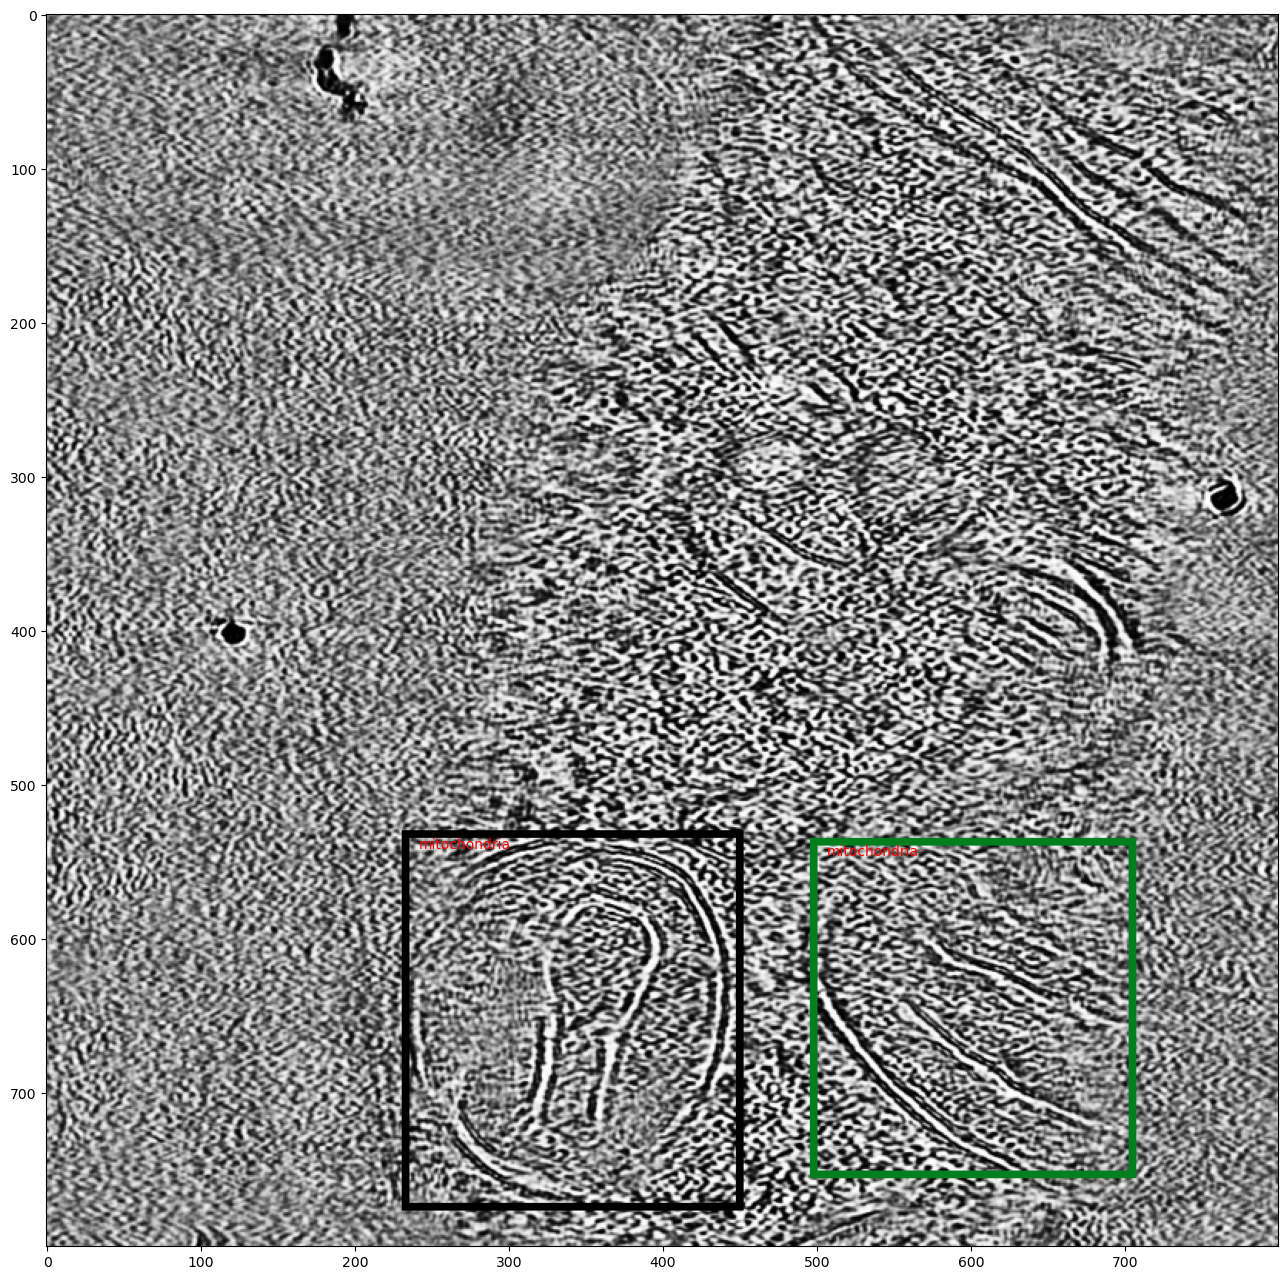

In [101]:
importlib.reload(postprocess)
importlib.reload(utils)
take = 290
q = df["z"]

subdf = df
# subdf = subdf[(subdf["label"] != "")]
subdf = subdf[(subdf["item_id"] != "")]
# subdf = subdf[subdf["label_id"] != -1]
# subdf = subdf[(subdf["nucleus"] > 0.85)]
subdf = subdf[subdf["z"] == take]
# print(subdf["label_id"].value_counts())
# subdf = subdf[subdf["ribo"] > 0.8]
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf  

# subdf2 = df.loc[need2]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
# subdf2["names"] = subdf2["label"] + subdf2["label_id"].astype("str")
names = list(subdf2["label"])
# print(names)
labels = {"bboxes": bboxes, "labels": names} 
plt.figure(figsize=(16,16))
utils.drawannotation(img, labels, font_size=10)
plt.show()
plt.close()


/tmp/ipykernel_561640/2035375691.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


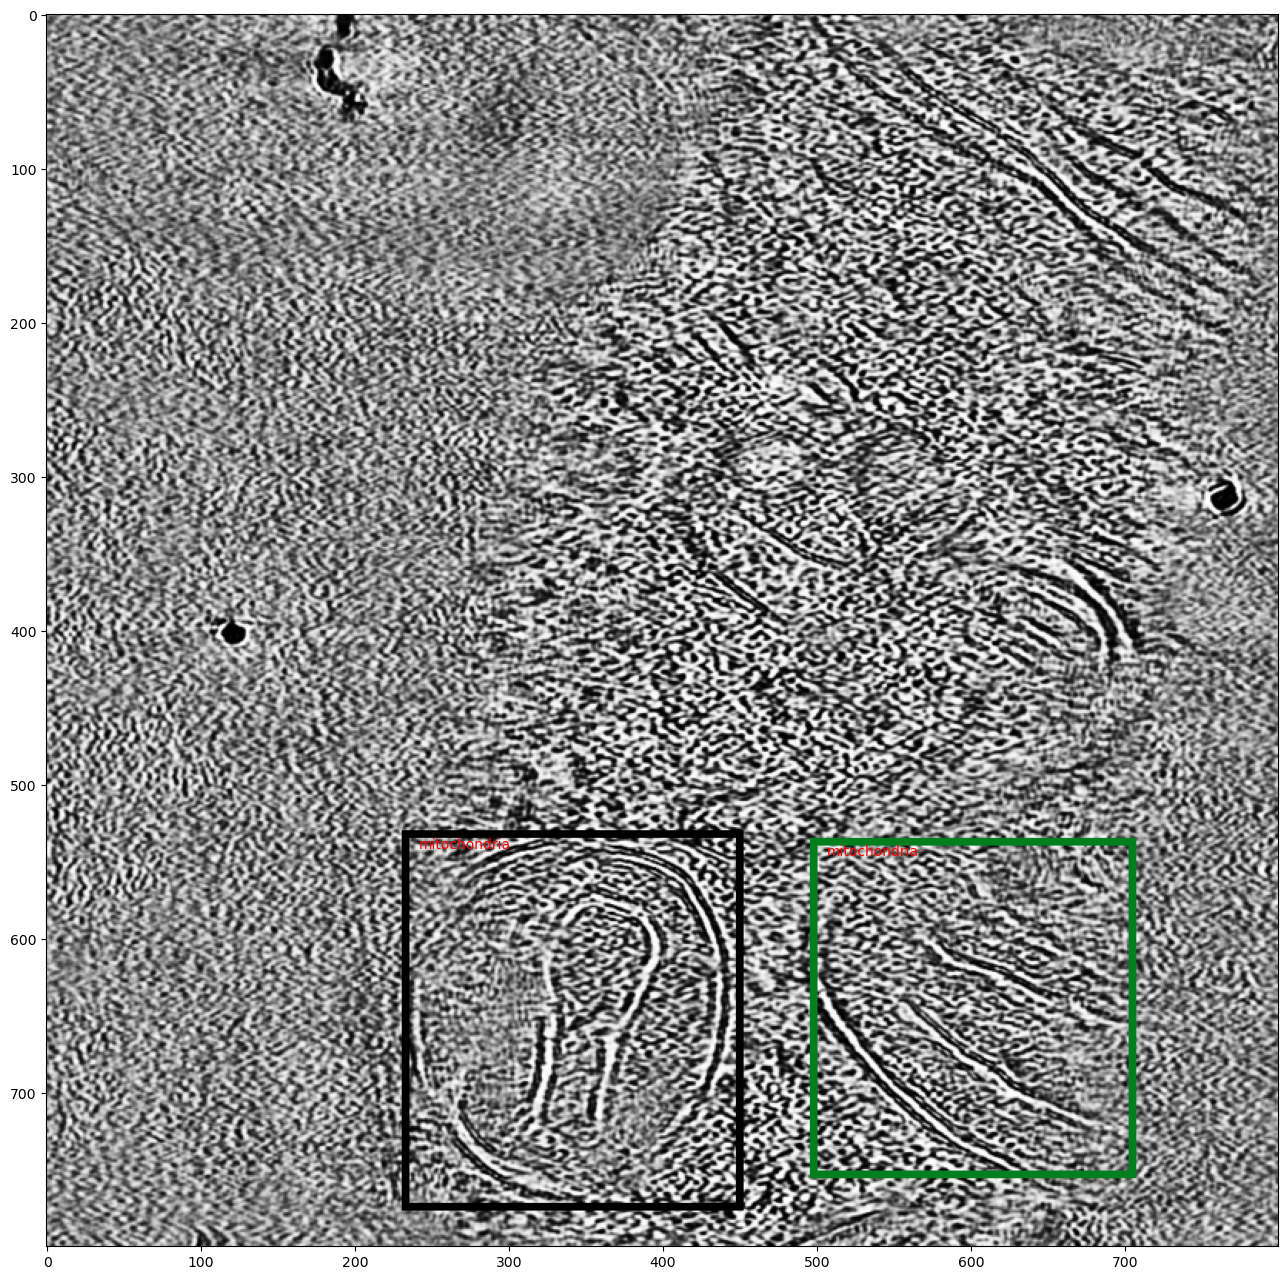

In [102]:
importlib.reload(postprocess)
importlib.reload(utils)
take = 290
q = df["z"]

subdf = df
subdf = subdf[(subdf["label"] != "")]
# subdf = subdf[(subdf["item_id"] != "")]
# subdf = subdf[subdf["label_id"] != -1]
# subdf = subdf[(subdf["nucleus"] > 0.85)]
subdf = subdf[subdf["z"] == take]
# print(subdf["label_id"].value_counts())
# subdf = subdf[subdf["ribo"] > 0.8]
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf  

# subdf2 = df.loc[need2]

""" if use dbscan results """
subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
# subdf2["names"] = subdf2["label"] + subdf2["label_id"].astype("str")
names = list(subdf2["label"])
# print(names)
labels = {"bboxes": bboxes, "labels": names} 
plt.figure(figsize=(16,16))
utils.drawannotation(img, labels, font_size=10)
plt.show()
plt.close()


In [18]:
subdf2.head()

,z,x,y,w,h,ribo,mitochondria,nucleus,endoplasmic_reticulum_or_Golgi,None,max,largest,unlabeled,label,label_id,class_value,names
13222,320,0.578601,0.533930,0.241937,0.382792,0.000883,0.655678,0.012548,0.223271,0.107620,0.655678,mitochondria,False,mitochondria,78,0.655678,mitochondria78
13392,320,0.343157,0.164455,0.311755,0.286436,0.000062,0.938930,0.023234,0.011201,0.026572,0.938930,mitochondria,False,mitochondria,49,0.938930,mitochondria49
13415,320,0.399047,0.420609,0.193202,0.209850,0.001396,0.355903,0.005724,0.541200,0.095777,0.541200,endoplasmic_reticulum_or_Golgi,False,mitochondria,50,0.355903,mitochondria50
13477,320,0.141479,0.421038,0.201424,0.282281,0.000355,0.841609,0.010037,0.096348,0.051651,0.841609,mitochondria,False,mitochondria,2,0.841609,mitochondria2
13481,320,0.767421,0.140735,0.464353,0.298985,0.000095,0.835429,0.110380,0.006507,0.047589,0.835429,mitochondria,False,mitochondria,87,0.835429,mitochondria87


In [45]:
len(df[df["nucleus"] > 0.3])

30

In [ ]:
# take one slice and visualize
take = 250
q = df["z"]

# subdf = df
# subdf = df[df["label"] == "nucleus"]
subdf = subdf[(subdf["label"] != "")]
# subdf = subdf[(subdf["nucleus"] > 0.6)]
subdf = subdf[subdf["z"] == take]
print(subdf["label_id"].value_counts())
# subdf = subdf[subdf["ribo"] > 0.8]
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf  

# subdf2 = df.loc[need2]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": ["need"] * len(bboxes)} 
plt.figure(figsize=(16,16))
utils.drawannotation(img, labels, font_size=1)
plt.show()
plt.close()

q = df["z"]

subdf = df
# subdf = subdf[(subdf["label"] != "")]
subdf = subdf[subdf["z"] == take]
subdf = subdf[subdf["None"] < 0.5]
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]

img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf  

# subdf2 = df.loc[need2]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": ["need"] * len(bboxes)} 
plt.figure(figsize=(16,16))
utils.drawannotation(img, labels, font_size=10)
plt.show()
plt.close()

t = dataset.__getitem__(pos=take)
# print(t["labels"])
# print("yes")
plt.figure(figsize=(16,16))
plt.imshow(t["pixel_values"][1], cmap="gray")
# utils.drawannotation(t["pixel_values"], t["labels"], mask=True)

In [271]:
importlib.reload(postprocess)
model = model.eval() 
model = model.cuda(0)
mask_thres = {
    "ribo":0.75, 
    "hsp60":0.75, 
    "mitochondria":0.6,
    "nucleus":0.5,
    "endoplasmic_reticulum_or_Golgi":0.6,
    
}
prepare_mask_input = {
    "nucleus":{"class_id":1, "min_length": 50, "extend": 10, "expand":0.03}, 
    "mitochondria":{"class_id":0, "min_length": 40, "extend": 10, "expand":0.03}, 
    "endoplasmic_reticulum_or_Golgi":{"class_id":3, "min_length": 30, "extend": 5, "expand":0.03}, 
    "ribo":{"class_id":0, "min_length": 20, "extend": 0, "expand":0.03}, 
    "hsp60":{"class_id":0, "min_length": 12, "extend": 0, "expand":0.03}, 
}
refine_mask = {
    "nucleus":{"smooth": 4.0, "morph_open_kernal_size":(7, 7), "morph_close_kernal_size": (7, 7), "blur_ksize": (25, 25), "max_contours": 1, "apply_convex_hull":False}, 
    "mitochondria":{"smooth": 4.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (15, 15), "max_contours": 1, "apply_convex_hull":False}, 
    "endoplasmic_reticulum_or_Golgi":{"smooth": 1.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (11, 11), "max_contours": 1, "contour_area_threshold":250, "apply_convex_hull":False}, 
    "ribo":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
    "hsp60":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
}
stage1_output = {}
build_masks = {
    "ribo": np.zeros((500, 800, 800), dtype=int),
    "hsp60": np.zeros((500, 800, 800), dtype=int),
    "mitochondria": np.zeros((500, 800, 800), dtype=int),
    "nucleus": np.zeros((500, 800, 800), dtype=int),
    "endoplasmic_reticulum_or_Golgi": np.zeros((500, 800, 800), dtype=int),
    
}
all_inputs = {}
for (label, label_id), r in df.groupby(["label", "label_id"]):
    if label == "ribo":
        continue
    if label == "":
        continue
    if label_id == -1:
        continue
    print(label, label_id, len(r))
    # if label == "ribo":
    #     continue
    if "%s_%s"%(label, label_id) in all_inputs:
        continue
    inputs, stage1_output = postprocess.getMaskInputs(r, model, dataset, **prepare_mask_input[label], stage1_outputs=stage1_output)
    # inputs = postprocess.getMaskInputsStage2(
    #     r,
    #     dataset, 
    #     **prepare_mask_input[label],
    #     res = res
    # )
    all_inputs["%s_%s"%(label, label_id)] = inputs
    smoothed_masks = postprocess.getMasks(model, inputs, refine_mask[label]["smooth"], on_z_only=True)

    minz = np.min(list(inputs.keys()))
    maxz = np.max(list(inputs.keys()))
    t = np.max(smoothed_masks)
    # masks = [] 
    for i in range(len(smoothed_masks)):
        mask = smoothed_masks[i]
        # box = inputs[i + minz]["input_mask"]
        # t1 = (mask * box).sum() / box.sum()
        # t2 = (mask * (1 - box)).sum() / (1 - box).sum()
        thres = t*mask_thres[label]
        refined_mask = postprocess.refineMask(
            mask,
            threshold = thres,
            **refine_mask[label],
        )
        smoothed_masks[i] = refined_mask
    smoothed_masks = smoothed_masks.astype(np.int32)
    
    for i in range(minz, maxz+1):
        build_masks[label][i][smoothed_masks[i-minz]>1] = (label_id+1)
        # masks.append(refined_mask)
    
    

mitochondria 0 234
mitochondria 1 99
nucleus 1 78


In [14]:
all_y= [i.y for i in graphs]
all_y = np.concatenate(all_y, axis=0)
all_x = [i.x for i in graphs]
all_x = np.concatenate(all_x, axis=0)
all_box_mask = [i.box_masks for i in graphs]
all_box_mask = np.concatenate(all_box_mask, axis=0)
all_itemid = [i.item_id for i in graphs]
all_itemid = np.concatenate(all_itemid, axis=0)
mlabel = np.zeros_like(all_box_mask, dtype=np.int32)-1
cnt = 0
for i in range(len(mlabel)):
    if all_box_mask[i]:
        mlabel[i] = cnt
        cnt += 1
# allres = {}

all_labels = [i.y.numpy() for i in graphs]
all_labels = np.concatenate(all_labels)
all_item_id = [i.item_id for i in graphs]
all_item_id = np.concatenate(all_item_id)
all_x = [i.x for i in graphs]
all_x = torch.cat(all_x, dim=0) 
df["annotation"] = all_labels
df["item_id"] = all_item_id
df["z"] = all_x[:, 0].numpy()*500
df["z"] = df["z"].round(0).astype(int)# df["item_id"]

In [6]:
df["item_id"].value_counts()

item_id
                  1537
mitochondria_1     256
nucleus_1          151
mitochondria_2      85
Name: count, dtype: int64

In [7]:
all_pv = {} 
for i in range(np.min(df["z"]), np.max(df["z"])+1):
    if i in all_pv:
        continue
    all_pv[i] = dataset.__getitem__(pos=i)["pixel_values"]

In [ ]:
refine_mask = {
    "nucleus":{"smooth": -5.0, "morph_open_kernal_size":(7, 7), "morph_close_kernal_size": (7, 7), "blur_ksize": (25, 25), "max_contours": 1, "apply_convex_hull":False}, 
    "mitochondria":{"smooth": -8.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (15, 15), "max_contours": 1, "apply_convex_hull":True}, 
    "endoplasmic_reticulum_or_Golgi":{"smooth": 1.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (11, 11), "max_contours": 1, "contour_area_threshold":250, "apply_convex_hull":False}, 
    "ribo":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
    "hsp60":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
}
mask_thres = {
    "ribo":0.75, 
    "hsp60":0.75, 
    "mitochondria":0.55,
    "nucleus":0.7,
    "endoplasmic_reticulum_or_Golgi":0.6,
    
}
all_res = {} 
before = {}
gth = {}
iou = {}

model.stage = "stage mask"
model.mask_head.TF = 1.0
model = model.cpu()
need = []
for i, r in df.groupby("item_id"):
    if not (i.startswith("nucleus") or i.startswith("mitochondria")):
        continue
    # print(i, len(r))
    inputs = {}  
    for j, row in r.iterrows():
        
        inputs[row["z"]] = {
            "id": j,
            "embed": all_x[j][-256:].unsqueeze(0).to(model.device),
            "bboxes": all_x[j][1:5].unsqueeze(0).to(model.device),
            "image": all_pv[row["z"]].unsqueeze(0).float().to(model.device),
            # "image": dataset.__getitem__(pos=row["z"])["pixel_values"].unsqueeze(0).float().to(model.device)
        }
        # if row["z"] == 290:
        #     need.append(inputs[row["z"]])
        #     print(j)
        # break
    # res = postprocess.getMasks(model, inputs, refine_mask[i.split("_")[0]]["smooth"], on_z_only=True)
    label = i[:i.find("_")]
    smoothed_masks = postprocess.getMasks(model, inputs, refine_mask[label]["smooth"], on_z_only=False)

    minz = np.min(list(inputs.keys()))
    maxz = np.max(list(inputs.keys()))
    t = np.max(smoothed_masks)
    # masks = [] 
    for i in range(len(smoothed_masks)):
        pmask = smoothed_masks[i]
        before[inputs[i + minz]["id"]] = pmask
        gth[inputs[i + minz]["id"]] = masks[mlabel[inputs[i + minz]["id"]]][2]
        # box = inputs[i + minz]["input_mask"]
        # t1 = (mask * box).sum() / box.sum()
        # t2 = (mask * (1 - box)).sum() / (1 - box).sum()
        thres = t*mask_thres[label]
        refined_mask = postprocess.refineMask(
            pmask,
            threshold = thres,
            **refine_mask[label],
        )
        # smoothed_masks[i] = refined_mask
        all_res[inputs[i + minz]["id"]] = refined_mask
        iou[inputs[i + minz]["id"]] = postprocess.calc_iou(refined_mask, masks[mlabel[inputs[i + minz]["id"]]][2])
        


In [55]:
pred_mask = all_res[453]
true_mask = gth[453]
pred_mask = (pred_mask > 0)#.astype(float)
true_mask = (true_mask > 0)#.astype(float)

intersection = np.sum(pred_mask&true_mask)
union = np.sum(pred_mask) + np.sum(true_mask) - intersection
intersection, union

(56920, 21422)

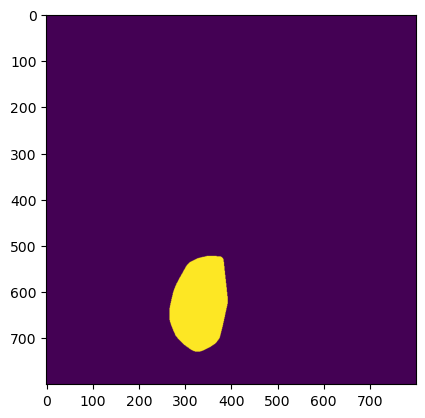

In [56]:
plt.imshow(pred_mask)

TypeError: Invalid shape (5, 800, 800) for image data

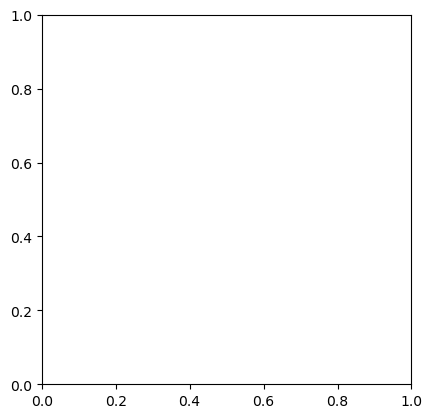

In [58]:
plt.imshow(true_mask)

In [47]:
np.max(pred_mask), np.max(true_mask)

(1.0, 1.0)

In [54]:
np.sum(pred_mask), np.sum(true_mask), np.sum((pred_mask+true_mask))

(20233.0, 58109.0, 159274.0)

In [37]:
np.max(pred_mask)

True

In [34]:
np.max(all_res[453])

255

In [32]:
postprocess.calc_iou(all_res[453], gth[453])

2.6570815049948653

In [26]:
iou

{37: 1.9538858589793533,
 453: 2.6570815049948653,
 866: 3.25362865639842,
 1270: 3.258748719699556,
 1664: 3.1595298068849704,
 45: 3.2411297852474323,
 461: 3.2310492943342197,
 872: 3.278529475745051,
 1275: 3.058557783323294,
 1668: 2.7330241109857507,
 49: 2.3721568315571813,
 465: 2.576989247311828,
 876: 2.972423053088205,
 1279: 3.43350945968979,
 1672: 3.920667845484222,
 53: 4.334661888334394,
 469: 4.113304263888427,
 880: 3.9358074222668002,
 1284: 3.7498492260269383,
 1677: 3.564756408535767,
 58: 3.2930305711196306,
 475: 3.292550248939701,
 885: 3.4248735853599808,
 1291: 3.5682188694904706,
 1683: 3.711126711126711,
 65: 3.8169042303509073,
 482: 3.665434115859776,
 892: 3.5410030694388137,
 1296: 3.276280739141407,
 1690: 3.2147664577255264,
 71: 3.11765572080695,
 487: 3.3283629078420147,
 896: 3.4404012320440485,
 1303: 3.640762579655729,
 1697: 3.8671751368459284,
 79: 3.9930894614286787,
 494: 4.276549619955037,
 903: 4.212941301573799,
 1312: 4.103665611814346,
 1

In [169]:
need = []
for i, r in df.groupby("item_id"):
    if not (i.startswith("nucleus") or i.startswith("mitochondria")):
        continue
    # print(i, len(r))
    inputs = {}  
    for j, row in r.iterrows():
        if not row["z"] == 290:
            continue
        need.append({
            "id": j,
            "embed": all_x[j][-256:].unsqueeze(0).to(model.device),
            "bboxes": all_x[j][1:5].unsqueeze(0).to(model.device),
            "image": dataset.__getitem__(pos=row["z"])["pixel_values"].unsqueeze(0).float().to(model.device)
        })
        # if row["z"] == 290:
        #     print(inputs[row["z"]])

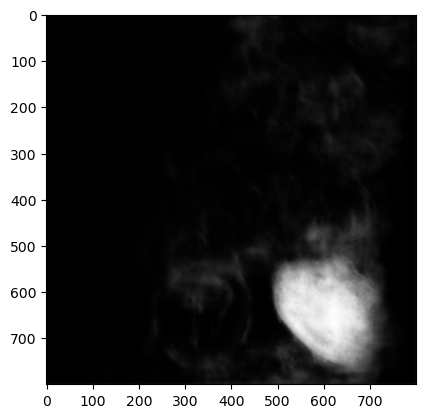

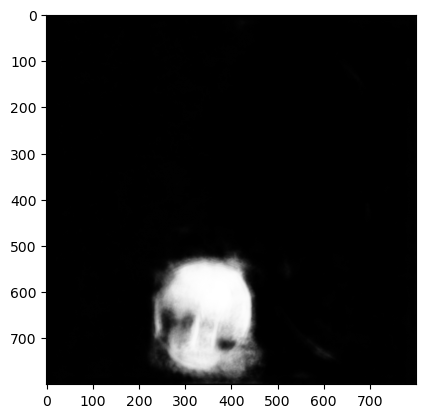

In [179]:

o1 = model(pixel_values = need[0]["image"], embed = need[0]["embed"], box = need[0]["bboxes"])
o2 = model(pixel_values = need[1]["image"], embed = need[1]["embed"], box = need[1]["bboxes"])
o1 = torch.sigmoid(o1).detach().cpu().numpy()
o2 = torch.sigmoid(o2).detach().cpu().numpy()
plt.imshow(o1[0], cmap="gray")
plt.show()
plt.close()
plt.imshow(o2[0], cmap="gray")
# plt.imshow(before[165], cmap="gray")


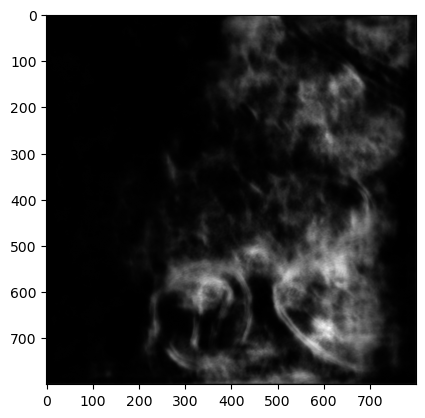

In [155]:
plt.imshow(o1[0], cmap="gray")

In [164]:
refine_mask = {
    "nucleus":{"smooth": 4.0, "morph_open_kernal_size":(7, 7), "morph_close_kernal_size": (7, 7), "blur_ksize": (25, 25), "max_contours": 1, "apply_convex_hull":False}, 
    "mitochondria":{"smooth": 4.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (15, 15), "max_contours": 1, "apply_convex_hull":False}, 
    "endoplasmic_reticulum_or_Golgi":{"smooth": 1.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (11, 11), "max_contours": 1, "contour_area_threshold":250, "apply_convex_hull":False}, 
    "ribo":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
    "hsp60":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
}
mask_thres = {
    "ribo":0.75, 
    "hsp60":0.75, 
    "mitochondria":0.6,
    "nucleus":0.75,
    "endoplasmic_reticulum_or_Golgi":0.6,
    
}
all_res_new = {}
before = {}
model.stage = "stage mask" 
# for (label, label_id) in zip(("mitochondria", "nucleus"), (1, 2)):
for i in ["mitochondria_1", "mitochondria_2", "nucleus_1"]:
    subdf = df[df["item_id"] == i]
    # subdf = df[df["annotation"] == label_id]
    for i, r in subdf.iterrows():
        x = all_x[i][-256:].unsqueeze(0).to(model.device)
        boxes = all_x[i][1:5].unsqueeze(0).to(model.device)
        pv = all_pv[r["z"]].unsqueeze(0).float().to(model.device)
        # data = dataset.__getitem__(pos=r["z"])
        # pv = data["pixel_values"].unsqueeze(0).float().to(model.device)
        with torch.no_grad():
            out = model(pixel_values = pv, embed = x, box = boxes) 
            out = torch.sigmoid(out).detach().cpu().numpy()
        before[i] = out.squeeze(0)
        thres = np.max(out)*0.6
        refined_mask = postprocess.refineMask(
            out.squeeze(0),
            threshold = thres,
            **refine_mask[label],
        )
        all_res_new[i] = refined_mask


In [24]:
all_res.keys()

dict_keys([24, 284, 536, 796, 1056, 27, 287, 539, 799, 1059, 29, 289, 542, 801, 1061, 31, 291, 544, 803, 1063, 34, 294, 547, 806, 1066, 37, 297, 551, 809, 1070, 40, 300, 554, 812, 1073, 43, 303, 557, 815, 1076, 46, 306, 561, 819, 1080, 51, 312, 567, 825, 1086, 57, 318, 574, 832, 1093, 65, 325, 582, 841, 1103, 76, 335, 590, 848, 1111, 82, 341, 598, 856, 1117, 88, 347, 604, 862, 1123, 93, 353, 612, 870, 1130, 101, 360, 618, 879, 1137, 107, 366, 624, 885, 1143, 114, 372, 629, 889, 1145, 116, 375, 632, 893, 1148, 119, 379, 637, 896, 1151, 122, 382, 641, 900, 1155, 127, 388, 646, 905, 1159, 131, 392, 650, 910, 1164, 136, 396, 654, 914, 1168, 141, 401, 661, 921, 1174, 146, 405, 664, 926, 1180, 152, 411, 671, 932, 1186, 159, 418, 678, 939, 1192, 165, 422, 682, 941, 1194, 168, 424, 684, 944, 1198, 171, 428, 687, 946, 1203, 173, 432, 691, 950, 1206, 180, 436, 695, 953, 1209, 184, 439, 699, 956, 1212, 187, 443, 703, 960, 1216, 193, 448, 710, 963, 1223, 194, 449, 711, 970, 1226, 197, 452, 714, 97

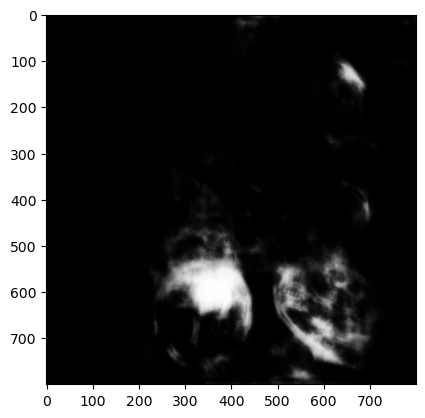

In [166]:
plt.imshow(before[164], cmap="gray")

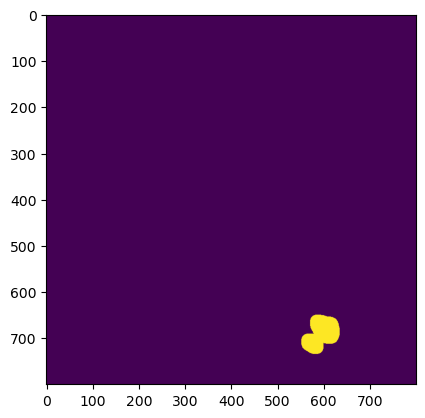

In [163]:
plt.imshow(all_res_new[165])

In [22]:
len(iou), len(all_res)

(492, 492)

In [23]:
nucleus = np.zeros((500, 800, 800), dtype=int)
mitochondria = np.zeros((500, 800, 800), dtype=int)
mito_iou = []
nuc_iou = []
for i in all_res:
    itemid = df.loc[i]["item_id"]
    if df.loc[i]["item_id"].startswith("nucleus"):
        nuc_iou.append(iou[i])
        nucleus[df.loc[i]["z"]][all_res[i]>1] += int(df.loc[i]["item_id"].split("_")[-1])
    if df.loc[i]["item_id"].startswith("mitochondria"):
        mito_iou.append(iou[i])
        mitochondria[df.loc[i]["z"]][all_res[i]>1] += int(df.loc[i]["item_id"].split("_")[-1])

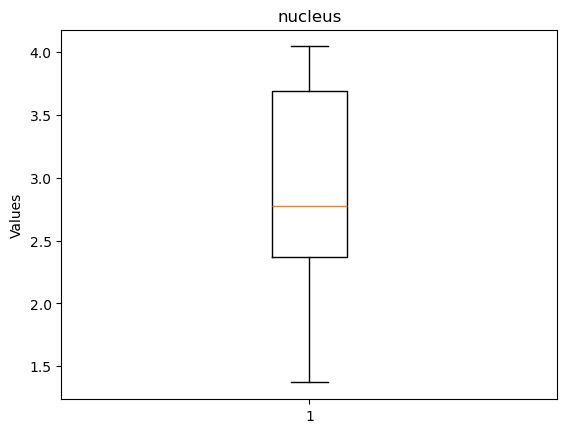

In [25]:
import matplotlib.pyplot as plt

# Example data
# data = iou_scores

# Create box plot
plt.boxplot(nuc_iou)

# Add labels and title
plt.title("nucleus")
plt.ylabel("Values")

# Show the plot
plt.show()


In [208]:
np.save("/home/feity/cryoem/temp/3Dresults/sllt39_nucleus", nucleus)
np.save("/home/feity/cryoem/temp/3Dresults/sllt39_mitochondria", mitochondria)

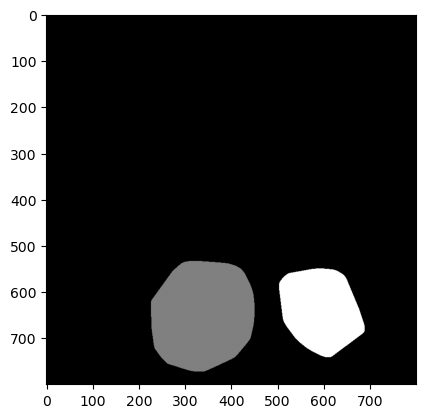

In [19]:
plt.imshow(mitochondria[280], cmap="gray")

In [96]:
from scipy.sparse import csr_matrix
from scipy.sparse import save_npz
for i in all_res_new:
    r = df.iloc[i]
    mat = all_res_new[i]
    mat = csr_matrix(mat)
    save_npz("/home/feity/cryoem/res/res/TS005/%s_%d.npz"%(r["item_id"], r["z"]), mat)
    # print(r)
    # break
    # label = df.loc[i]["label"]
    # label_id = df.loc[i]["label_id"]
    # z = df.loc[i]["z"]
    # build_masks[label][z][all_res[i]>1] = (label_id+1)

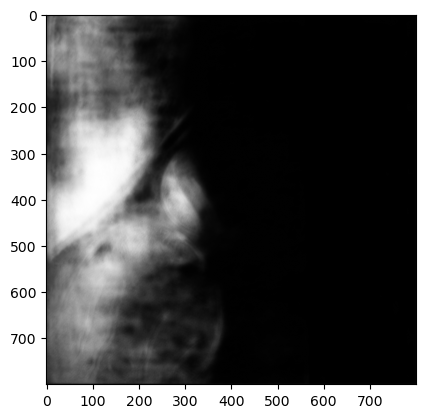

In [109]:
plt.imshow(before[idx[80]], cmap="gray")

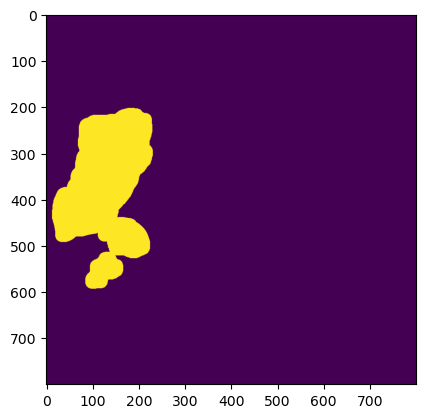

In [111]:
plt.imshow(all_res[idx[90]])

In [283]:
all_inputs.keys()

dict_keys(['mitochondria_0', 'mitochondria_1', 'nucleus_1'])

In [284]:
r = df[df["label"] == "nucleus"]
inputs, stage1_output = postprocess.getMaskInputs(r, model, dataset, **prepare_mask_input[label])
smoothed_masks = postprocess.getMasks(model, all_inputs["nucleus_1"], refine_mask[label]["smooth"], on_z_only=True)

In [289]:
inputs.keys()

dict_keys([154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274])

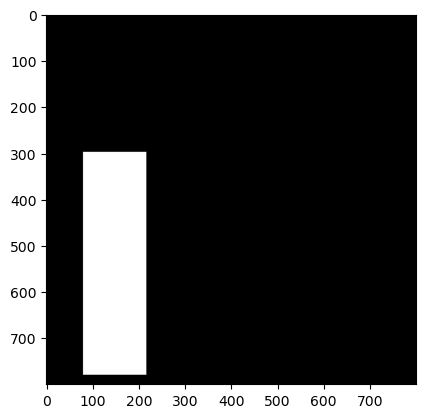

In [287]:
im = inputs[230]["input_mask"]
plt.imshow(im, cmap="gray")

In [ ]:
t = dataset.__getitem__(pos=250)
t["labels"]


{'bboxes': BoundingBoxes([[ 67.1172, 441.1111, 381.6250, 798.8889],
                [240.1797, 262.2222, 480.9141, 479.4445],
                [ 46.5938,   1.1111, 406.0312, 467.2223]], format=BoundingBoxFormat.XYXY, canvas_size=(800, 800)),
 'class_labels': tensor([0, 0, 1]),
 'names': ['mitochondria', 'mitochondria', 'nucleus'],
 'item_id': ['mitochondria_1', 'mitochondria_2', 'nucleus_1'],
 'orig_size': tensor([1440, 1024]),
 'size': tensor([800, 568]),
 'image_id': tensor(0),
 'boxes': tensor([[0.2805, 0.7750, 0.3931, 0.4472],
         [0.4507, 0.4635, 0.3009, 0.2715],
         [0.2829, 0.2927, 0.4493, 0.5826]]),
 'iscrowd': tensor([0, 0, 0]),
 'pos': 250}

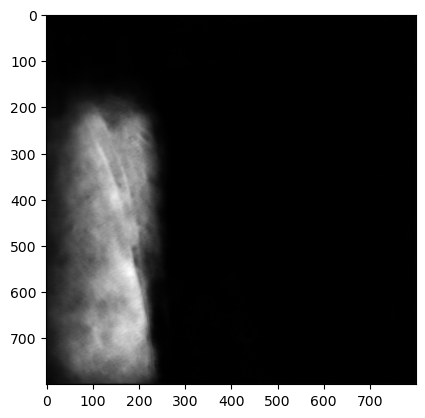

In [288]:
plt.imshow(smoothed_masks[40], cmap="gray")

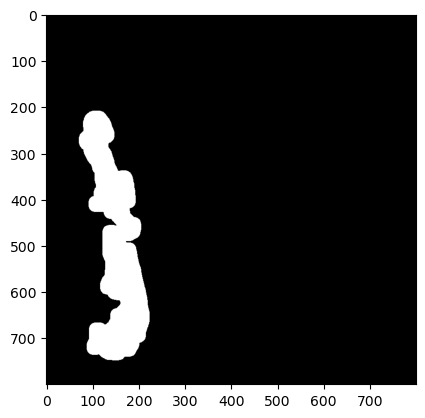

In [281]:
plt.imshow(build_masks["nucleus"][190], cmap="gray")

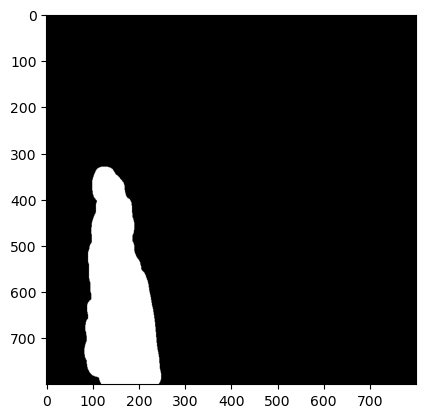

In [ ]:
mask = smoothed_masks[115]
refined_mask = postprocess.refineMask(
            mask,
            threshold = 0.7,
            **refine_mask["nucleus"],
        )
plt.imshow(refined_mask, cmap="gray")

In [64]:
all_inputs["nucleus_0"].keys()

dict_keys([132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266])

In [82]:
df = df[df["label"] != ""] 
df = df[df["label"] != "endoplasmic_reticulum_or_Golgi"]
df

,z,x,y,w,h,ribo,mitochondria,nucleus,endoplasmic_reticulum_or_Golgi,None,max,largest,unlabeled,label,label_id,class_value
16,142,0.410648,0.790173,0.137632,0.245771,0.000037,0.910858,0.001277,0.060220,0.027607,0.910858,mitochondria,False,mitochondria,0,0.910858
316,147,0.405009,0.788154,0.138562,0.247246,0.000121,0.913783,0.002662,0.047944,0.035489,0.913783,mitochondria,False,mitochondria,0,0.913783
527,147,0.127091,0.563242,0.261148,0.854781,0.002917,0.226400,0.436208,0.052934,0.281541,0.436208,nucleus,False,nucleus,0,0.226400
616,152,0.410954,0.780614,0.142644,0.246077,0.000056,0.927751,0.001614,0.047050,0.023529,0.927751,mitochondria,False,mitochondria,0,0.927751
827,152,0.124625,0.530187,0.197752,0.745500,0.005508,0.199215,0.473132,0.047821,0.274324,0.473132,nucleus,False,nucleus,0,0.199215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76414,376,0.767943,0.774059,0.329648,0.263176,0.001348,0.620175,0.034489,0.203644,0.140345,0.620175,mitochondria,False,mitochondria,1,0.620175
76714,381,0.758598,0.771810,0.334004,0.308671,0.000591,0.765817,0.019549,0.117267,0.096776,0.765817,mitochondria,False,mitochondria,1,0.765817
77014,386,0.759337,0.772461,0.338293,0.310968,0.001861,0.580003,0.036288,0.220725,0.161123,0.580003,mitochondria,False,mitochondria,1,0.580003
77144,391,0.800512,0.731329,0.227041,0.295938,0.002585,0.419382,0.078022,0.225478,0.274532,0.419382,mitochondria,False,mitochondria,1,0.419382


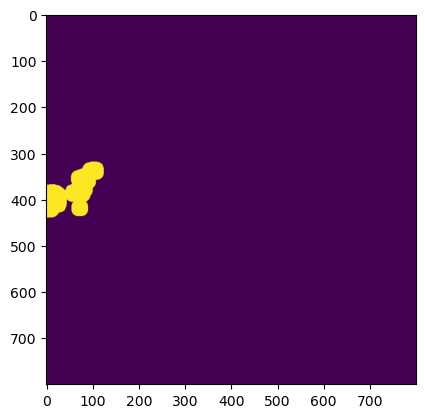

In [228]:
plt.imshow(build_masks["nucleus"][190])

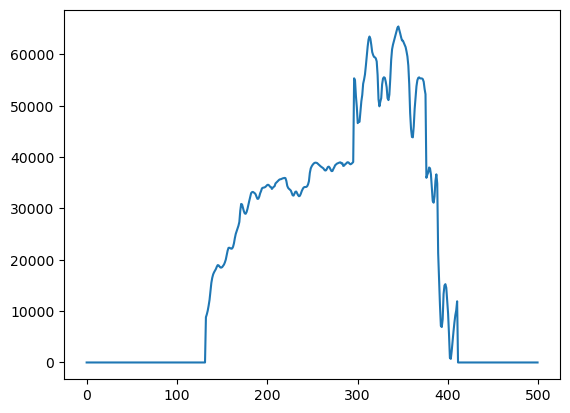

In [101]:
res = [] 
for i in range(500):
    res.append((d["masks"]["mitochondria"][i]>0).sum())
plt.plot(res)

In [ ]:
with open("/home/feity/cryoem/temp/results/sllt39_2.pkl", "wb") as f:
    pickle.dump({
        "df": df, 
        "masks": build_masks, 
        "inputs": all_inputs
    }, f)

In [75]:
with open("/home/feity/cryoem/temp/results/sllt39_1.pkl", "rb") as f:
    d = pickle.load(f)
# d["masks"]["mitochondria"] = build_masks["mitochondria"]
# with open("/home/feity/cryoem/temp/results/sllt39_1.pkl", "wb") as f:
#     pickle.dump(d, f)

In [77]:
masks = d["masks"]

In [236]:
with open("/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl","rb") as f:
    label = pickle.load(f)
with open("/home/feity/cryoem/temp/results/sllt39_1.pkl", "rb") as f:
    d = pickle.load(f)

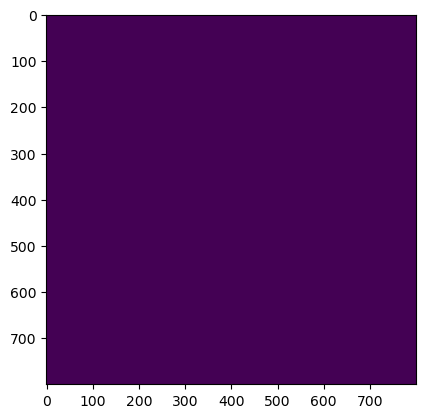

In [252]:
plt.imshow(d["masks"]["nucleus"][280])
np.save("../temp/280.npy", d["masks"]["nucleus"][280])

In [113]:
mitochondria = d["masks"]["mitochondria"]
mitochondria_label = label["masks"]["mitochondria"]

In [119]:
mitochondria_label

{400: <1024x1024 sparse matrix of type '<class 'numpy.uint16'>'
 	with 77256 stored elements in Compressed Sparse Row format>,
 395: <1024x1024 sparse matrix of type '<class 'numpy.uint16'>'
 	with 71360 stored elements in Compressed Sparse Row format>,
 399: <1024x1024 sparse matrix of type '<class 'numpy.uint16'>'
 	with 77256 stored elements in Compressed Sparse Row format>,
 398: <1024x1024 sparse matrix of type '<class 'numpy.uint16'>'
 	with 77256 stored elements in Compressed Sparse Row format>,
 397: <1024x1024 sparse matrix of type '<class 'numpy.uint16'>'
 	with 71360 stored elements in Compressed Sparse Row format>,
 396: <1024x1024 sparse matrix of type '<class 'numpy.uint16'>'
 	with 71360 stored elements in Compressed Sparse Row format>,
 390: <1024x1024 sparse matrix of type '<class 'numpy.uint16'>'
 	with 96894 stored elements in Compressed Sparse Row format>,
 394: <1024x1024 sparse matrix of type '<class 'numpy.uint16'>'
 	with 71360 stored elements in Compressed Spar

In [121]:
from PIL import Image
ious = []

In [122]:

for i in range(500):
    if np.sum(mitochondria[i] == 1) == 0:
        continue
    if i not in mitochondria_label or (i not in label["annotations"]["mitochondria"] or 1 not in label["annotations"]["mitochondria"][i]):
        continue
    mask = Image.fromarray(mitochondria_label[i].toarray())
    mask = mask.resize((800, 800), resample=Image.NEAREST)
    mask = np.array(mask)
    ious.append(calc_iou(mitochondria[i]==1, mask))
    
for i in range(500):
    if np.sum(mitochondria[i] == 2) == 0:
        continue
    if i not in mitochondria_label or (i not in label["annotations"]["mitochondria"] or 2 not in label["annotations"]["mitochondria"][i]):
        continue
    mask = Image.fromarray(mitochondria_label[i].toarray())
    mask = mask.resize((800, 800), resample=Image.NEAREST)
    mask = np.array(mask)
    ious.append(calc_iou(mitochondria[i]==2, mask))

# for i in range(500):
#     if np.sum(nucleus[i]) == 0:
#         continue
#     if i not in nucleus_label:
#         continue
#     mask = Image.fromarray(nucleus_label[i].toarray())
#     mask = mask.resize((800, 800), resample=Image.NEAREST)
#     mask = np.array(mask)
#     ious.append(calc_iou(nucleus[i], mask))

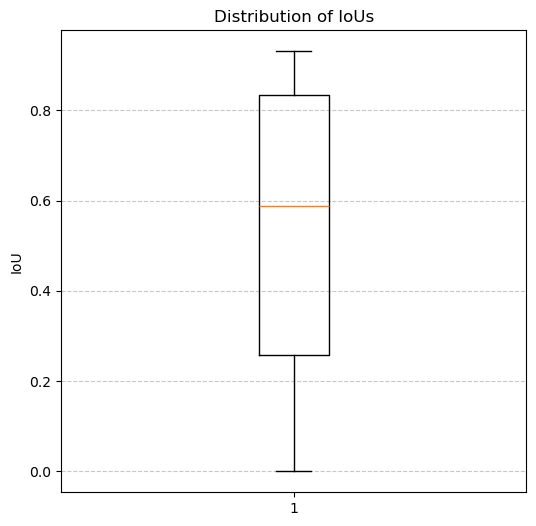

In [123]:
plt.figure(figsize=(6, 6))
plt.boxplot(ious, vert=True)
plt.ylabel("IoU")
plt.title("Distribution of IoUs")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [79]:
label.keys()

dict_keys(['annotations', 'masks', 'bboxes', 'mapclass', 'mrc', 'mrc_shape', 'mrc_path'])

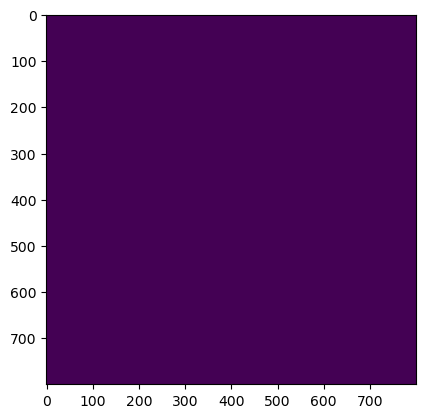

In [135]:
plt.imshow(build_masks["hsp60"][200])